<a href="https://colab.research.google.com/github/Zebedee2021/pyspt-v2/blob/main/tutorials/ch02_generation/01_waveforms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ch02 - 波形生成 | Waveform Generation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zebedee2021/pyspt-v2/blob/main/tutorials/ch02_generation/01_waveforms.ipynb)

本教程演示如何使用 `pyspt.waveforms` 模块生成常见信号波形，包括周期波、脉冲和调制信号。

This tutorial demonstrates how to generate common signal waveforms using the `pyspt.waveforms` module.

---

## 环境准备 | Setup

在 Google Colab 中运行时，需要先安装 PySPT：

In [1]:
# Install pyspt (only needed in Colab or fresh environments)
try:
    import pyspt
except ImportError:
    !pip install -q git+https://github.com/Zebedee2021/pyspt-v2.git
    import pyspt

print(f"PySPT version: {pyspt.__version__}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PySPT version: 2.0.0dev0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyspt.waveforms import (
    square, sawtooth, diric,
    gauspuls, gmonopuls, rectpuls, tripuls, pulstran,
    chirp, sinc
)

# Plot style
plt.rcParams["figure.figsize"] = (12, 3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

---
## 1. 周期波形 | Periodic Waveforms

### 1.1 方波 `square`

生成周期方波。`duty` 参数控制占空比（百分比 0–100，与 MATLAB 一致）。

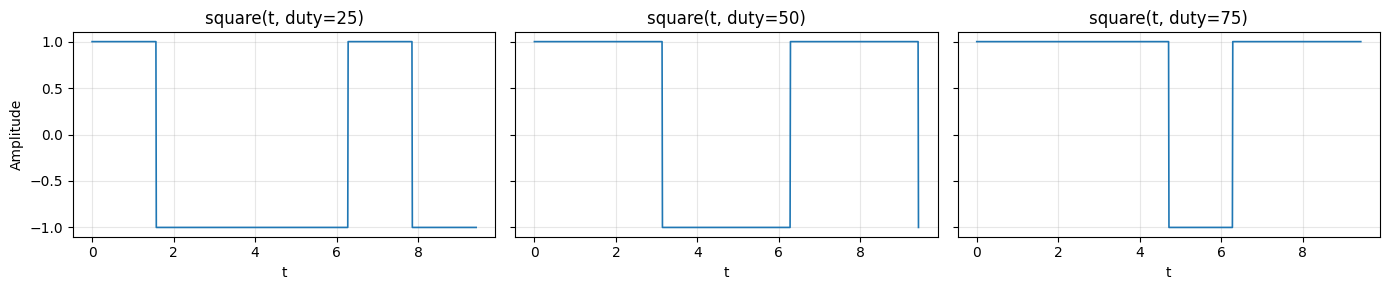

In [3]:
t = np.linspace(0, 3 * np.pi, 1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, duty in zip(axes, [25, 50, 75]):
    ax.plot(t, square(t, duty=duty), linewidth=1.2)
    ax.set_title(f"square(t, duty={duty})")
    ax.set_xlabel("t")
axes[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 1.2 锯齿波 `sawtooth`

`width=1` 生成锯齿波，`width=0.5` 生成三角波。

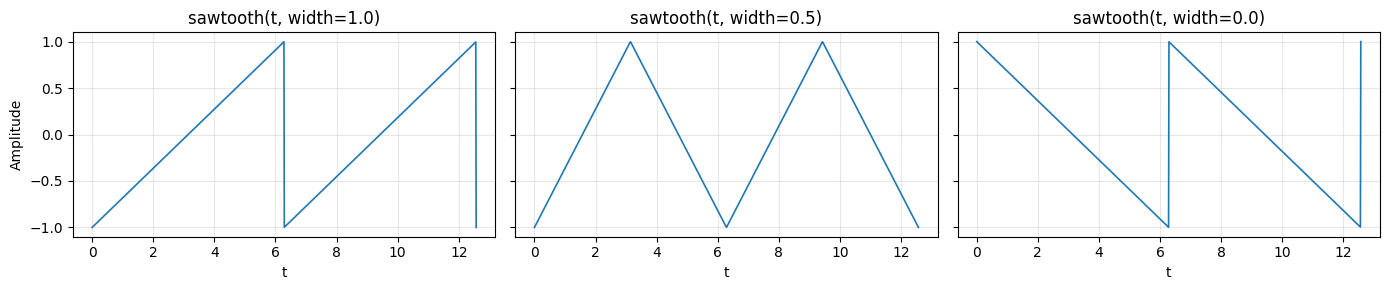

In [4]:
t = np.linspace(0, 4 * np.pi, 1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, w in zip(axes, [1.0, 0.5, 0.0]):
    ax.plot(t, sawtooth(t, width=w), linewidth=1.2)
    ax.set_title(f"sawtooth(t, width={w})")
    ax.set_xlabel("t")
axes[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 1.3 Dirichlet 函数 `diric`

Dirichlet 函数（周期 sinc），不同的 $n$ 值产生不同的主瓣宽度。

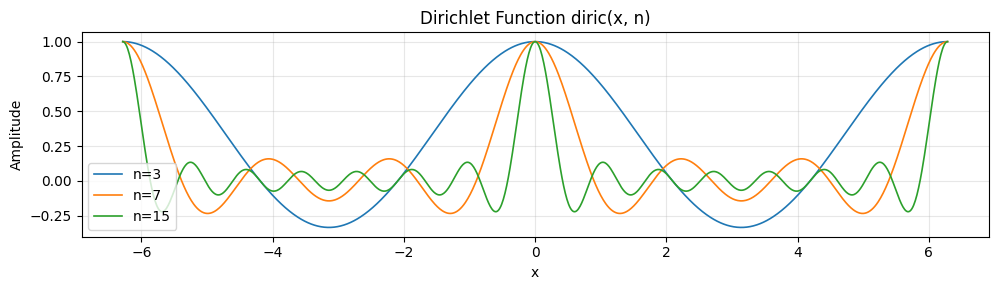

In [5]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(10, 3))
for n in [3, 7, 15]:
    ax.plot(x, diric(x, n), label=f"n={n}", linewidth=1.2)
ax.set_title("Dirichlet Function diric(x, n)")
ax.set_xlabel("x")
ax.set_ylabel("Amplitude")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. 脉冲波形 | Pulse Waveforms

### 2.1 高斯调制脉冲 `gauspuls`

生成高斯调制正弦脉冲。`fc` 是中心频率，`bw` 是相对带宽。

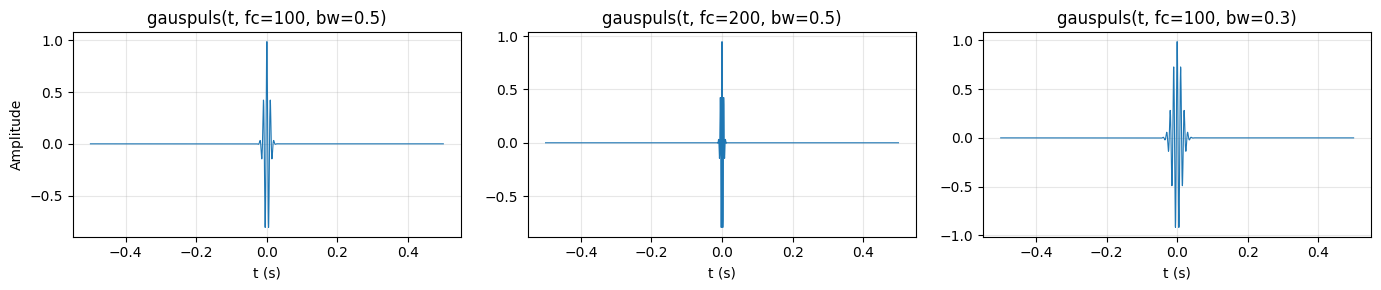

In [6]:
t = np.linspace(-0.5, 0.5, 2000)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (fc, bw) in zip(axes, [(100, 0.5), (200, 0.5), (100, 0.3)]):
    y = gauspuls(t, fc=fc, bw=bw)
    ax.plot(t, y, linewidth=0.8)
    ax.set_title(f"gauspuls(t, fc={fc}, bw={bw})")
    ax.set_xlabel("t (s)")
axes[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 2.2 高斯单脉冲 `gmonopuls`

生成高斯单脉冲（Gaussian monopulse），常用于雷达信号建模。

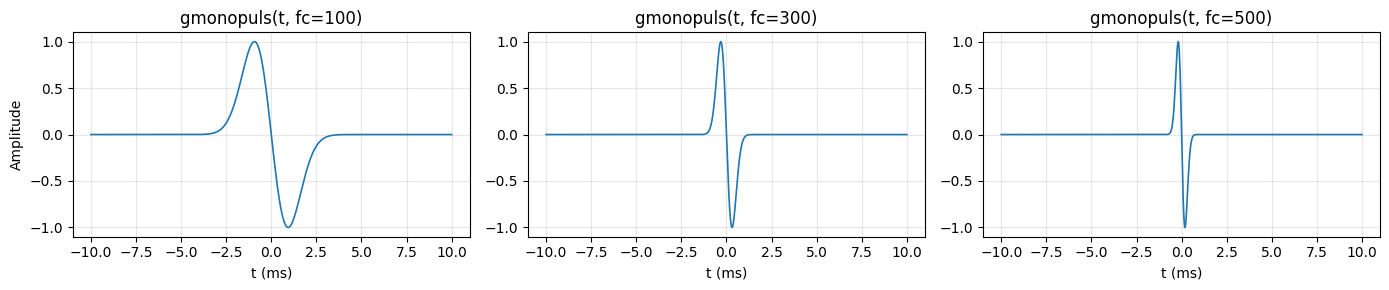

In [7]:
t = np.linspace(-0.01, 0.01, 1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, fc in zip(axes, [100, 300, 500]):
    y = gmonopuls(t, fc=fc)
    ax.plot(t * 1000, y, linewidth=1.2)
    ax.set_title(f"gmonopuls(t, fc={fc})")
    ax.set_xlabel("t (ms)")
axes[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 2.3 矩形脉冲 `rectpuls` 与 三角脉冲 `tripuls`

- `rectpuls(t, width)`: 矩形脉冲，边界点值为 0.5
- `tripuls(t, width, skew)`: 三角脉冲，`skew` 控制偏斜方向

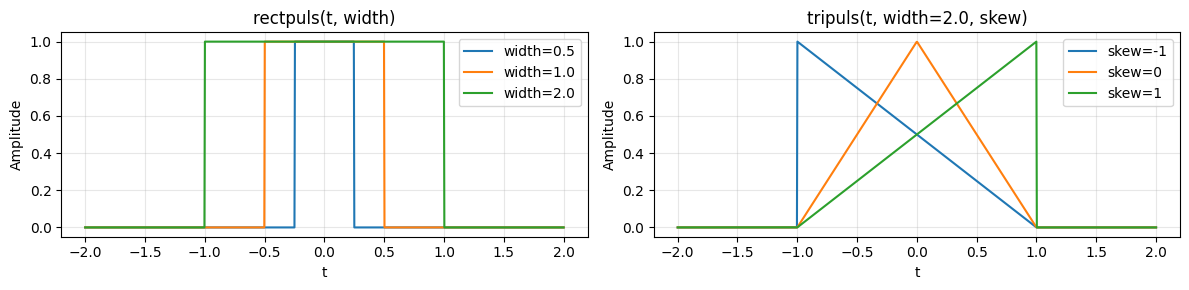

In [8]:
t = np.linspace(-2, 2, 1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# rectpuls
for w in [0.5, 1.0, 2.0]:
    axes[0].plot(t, rectpuls(t, width=w), label=f"width={w}", linewidth=1.5)
axes[0].set_title("rectpuls(t, width)")
axes[0].legend()

# tripuls
for skew in [-1, 0, 1]:
    axes[1].plot(t, tripuls(t, width=2.0, skew=skew), label=f"skew={skew}", linewidth=1.5)
axes[1].set_title("tripuls(t, width=2.0, skew)")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("t")
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 2.4 脉冲序列 `pulstran`

用单个脉冲函数生成脉冲序列，指定延迟和振幅。

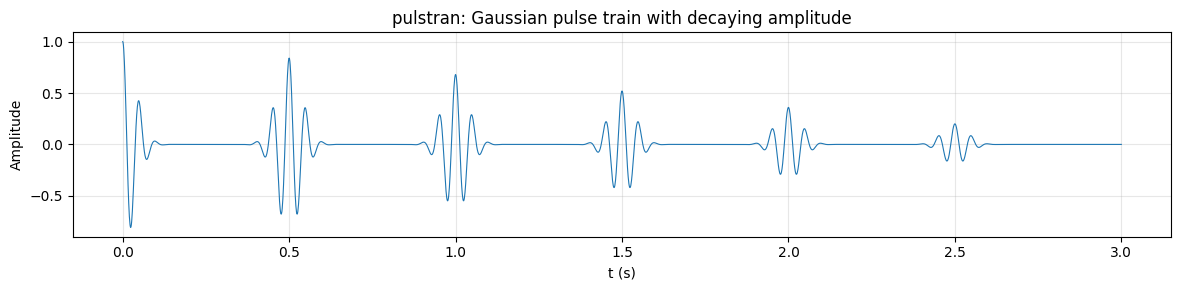

In [11]:
t = np.linspace(0, 3, 3000)

# Delays with decreasing amplitude
delays = np.column_stack([
    np.arange(0, 3, 0.5),
    np.linspace(1, 0.2, 6),
])

# Fix: Pass a lambda function to `pulstran` to include `fc` for `gauspuls`
y = pulstran(t, delays, func=lambda t_local: gauspuls(t_local, fc=20), fs=1000)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, y, linewidth=0.8)
ax.set_title("pulstran: Gaussian pulse train with decaying amplitude")
ax.set_xlabel("t (s)")
ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

---
## 3. 调制信号与特殊函数 | Modulated & Special

### 3.1 线性调频信号 `chirp`

Chirp 信号的频率随时间变化，支持 `linear`、`quadratic`、`logarithmic` 等方法。

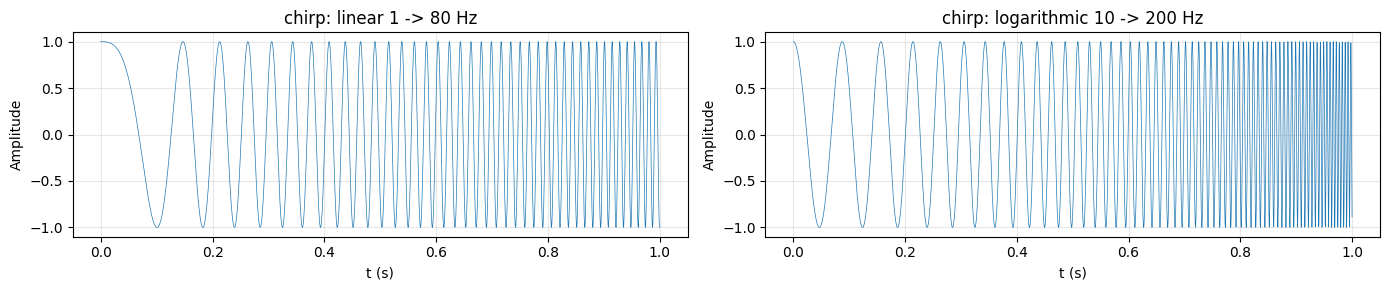

In [12]:
t = np.linspace(0, 1, 4000)

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

# Linear chirp
y1 = chirp(t, f0=1, t1=1, f1=80, method="linear")
axes[0].plot(t, y1, linewidth=0.5)
axes[0].set_title("chirp: linear 1 -> 80 Hz")

# Logarithmic chirp
y2 = chirp(t, f0=10, t1=1, f1=200, method="logarithmic")
axes[1].plot(t, y2, linewidth=0.5)
axes[1].set_title("chirp: logarithmic 10 -> 200 Hz")

for ax in axes:
    ax.set_xlabel("t (s)")
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

### 3.2 归一化 sinc 函数

$\text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}$，在信号采样和重建中起核心作用。

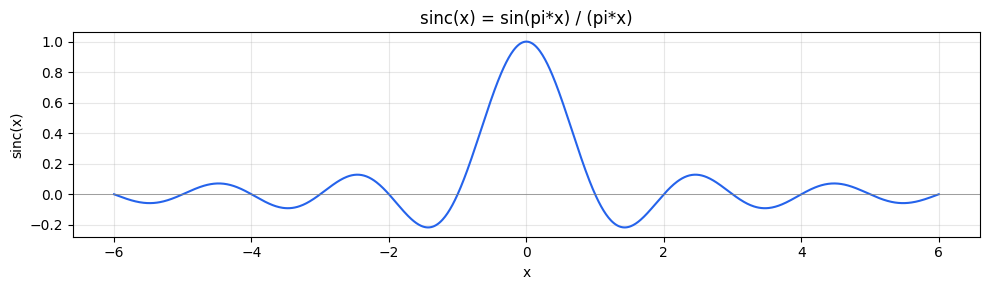

In [13]:
x = np.linspace(-6, 6, 1000)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, sinc(x), linewidth=1.5, color="#2563EB")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("sinc(x) = sin(pi*x) / (pi*x)")
ax.set_xlabel("x")
ax.set_ylabel("sinc(x)")
plt.tight_layout()
plt.show()

---
## 4. 综合示例：多种波形对比 | Combined Example

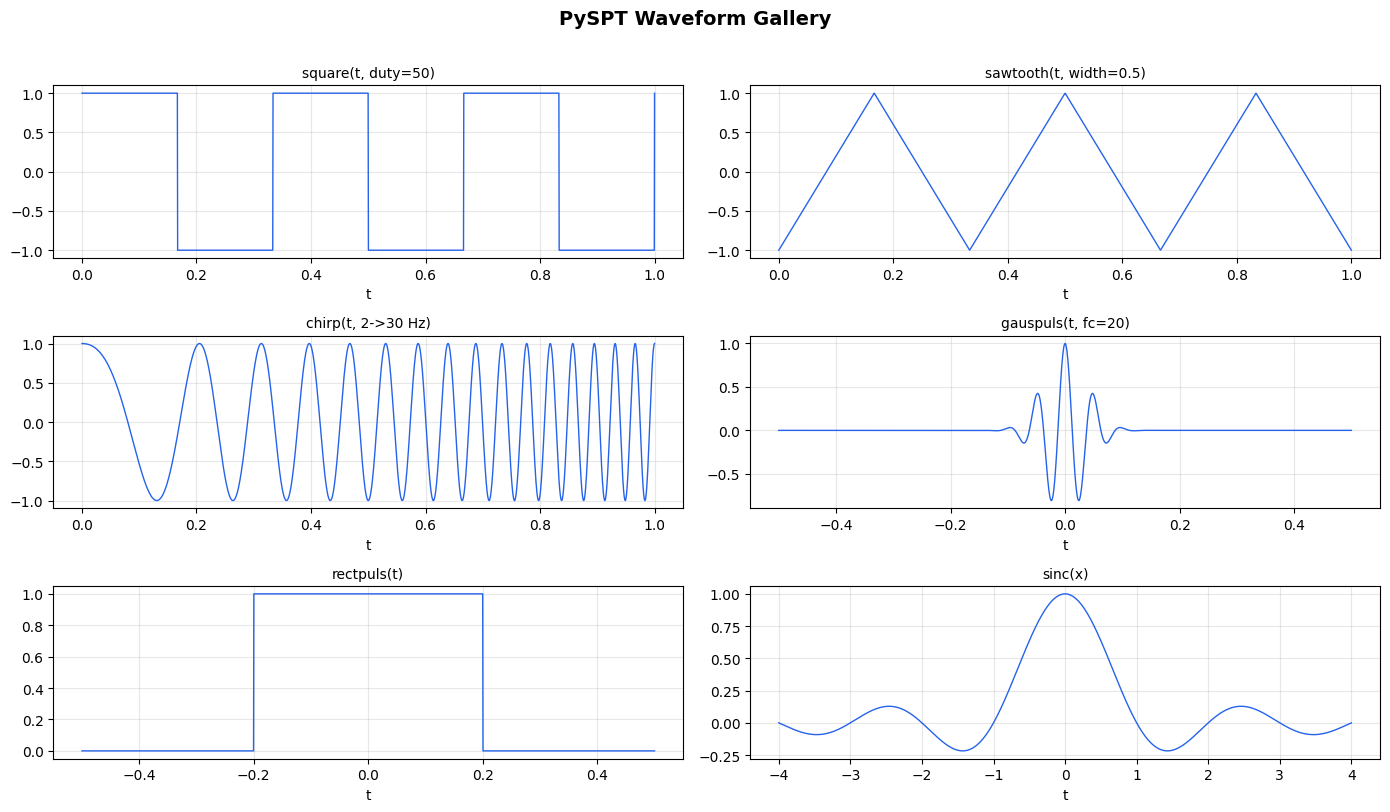

In [14]:
t = np.linspace(0, 1, 2000)
t_sym = np.linspace(-0.5, 0.5, 2000)

waveforms = [
    ("square(t, duty=50)", t, square(2*np.pi*3*t, duty=50)),
    ("sawtooth(t, width=0.5)", t, sawtooth(2*np.pi*3*t, width=0.5)),
    ("chirp(t, 2->30 Hz)", t, chirp(t, f0=2, t1=1, f1=30)),
    ("gauspuls(t, fc=20)", t_sym, gauspuls(t_sym, fc=20, bw=0.5)),
    ("rectpuls(t)", t_sym, rectpuls(t_sym, width=0.4)),
    ("sinc(x)", np.linspace(-4, 4, 2000), sinc(np.linspace(-4, 4, 2000))),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, (name, x, y) in zip(axes.ravel(), waveforms):
    ax.plot(x, y, linewidth=1.0, color="#2563EB")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("t")
plt.suptitle("PySPT Waveform Gallery", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---

## MATLAB 对照 | MATLAB Comparison

| PySPT (Python) | MATLAB | 说明 |
|:---|:---|:---|
| `square(t, duty=30)` | `square(t, 30)` | duty 均为百分比 |
| `sawtooth(t, width=0.5)` | `sawtooth(t, 0.5)` | 完全一致 |
| `chirp(t, 1, 1, 50)` | `chirp(t, 1, 1, 50)` | 参数顺序一致 |
| `gauspuls(t, fc=100)` | `gauspuls(t, 100)` | 默认参数一致 |
| `rectpuls(t, 0.5)` | `rectpuls(t, 0.5)` | 完全一致 |

---

*PySPT v2 · Beijing Institute of Technology · [GitHub](https://github.com/Zebedee2021/pyspt-v2)*